# 켈프 급감 조기경보: 165셀 최소 추가 실험 감사

## TL;DR

- **RQ1은 지지된다.** 현재 캐노피만으로도 다음 해 30% 이상 급감 셀을 연도 내에서 무작위보다 잘 순위화했다(macro within-year AP lift 0.177, 95% year-block CI 0.141–0.214).
- **RQ2는 부분 지지다.** 과거 변화는 작은 추가가치(Δ 0.024, 95% CI 0.006–0.045)가 있었지만, OISST와 CUTI/BEUTI는 같은 행 비교에서 추가가치를 보이지 않았다.
- **RQ3은 기본 순위화에는 지지되지만 추가 변수에는 제한적이다.** 2022년을 제외해도 결과가 유지됐고 모든 지역 외부검증에서 현재 상태 모델의 macro lift가 양수였다. 그러나 궤적·환경 증분은 지역별로 일관되지 않았다.
- 조사예산 20%에서 현재 상태 모델은 사건의 32.0%를 회수했다(무작위 기대 20%의 약 1.60배). 궤적의 실무 증가는 0.3%p에 불과했다.

## Context & Methods

이 노트북은 `scripts/41_build_expanded_noaa_features.py`와 `scripts/42_run_minimal_paper_extension.py`가 생성한 고정 산출물을 다시 계산하지 않고 감사한다. 모집단은 KelpWatch 165셀, 예측 대상은 현재 캐노피가 남은 cell-year의 다음 해 30% 이상 감소, 검증은 2005–2024 expanding window다. 모델은 고정 L2 로지스틱 회귀이며 하이퍼파라미터 탐색을 하지 않았다.

### Key Assumptions

1. `annual maximum canopy 30% 감소`는 생태학적 붕괴점이 아니라 사전에 정한 운영적 경보다.
2. macro within-year AP lift(AP−그해 유병률)를 주 지표로 사용한다. pooled AP만으로 연도 간 사건률 차이를 학습한 효과를 주장하지 않는다.
3. OISST는 0.25° 지역 열노출 proxy이고 현장 수온이 아니다. CUTI/BEUTI는 U.S. West Coast 31–47°N의 광역 용승·질산염 수송 proxy다.
4. 모든 변수는 예측 연도 전에 이용 가능한 값만 사용하고, 각 비교는 동일한 cell-year 행에서 수행한다.
5. 이전 파일럿을 본 뒤 고정한 확장 검증이므로 독립 확증·사전등록 실험으로 표현하지 않는다.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
RUN = ROOT / "outputs" / "experiments" / "20260814_minimal_paper_extension_v2"

summary = pd.read_csv(RUN / "model_summary.csv")
diffs = pd.read_csv(RUN / "bootstrap_differences.csv")
stress = pd.read_csv(RUN / "stress_2022.csv")
loyo = pd.read_csv(RUN / "leave_one_year_out.csv")
transfer = pd.read_csv(RUN / "leave_region_out_summary.csv")
checks = pd.read_csv(RUN / "quality_checks.csv")
env_checks = pd.read_csv(RUN / "environment_coverage_qc.csv")
decision = json.loads((RUN / "decision.json").read_text())

assert checks["passed"].all(), checks.loc[~checks["passed"]]
assert env_checks["passed"].all(), env_checks.loc[~env_checks["passed"]]
assert summary.loc[summary["domain"].eq("full_oisst_domain"), "n"].nunique() == 1
assert summary.loc[summary["domain"].eq("upwelling_supported_domain"), "n"].nunique() == 1
print(f"분석 품질 점검: {len(checks)}/{len(checks)} 통과")
print(f"환경자료 점검: {len(env_checks)}/{len(env_checks)} 통과")
print("검증기간:", checks.loc[checks["check"].eq("forecast_years"), "value"].iloc[0])

분석 품질 점검: 7/7 통과
환경자료 점검: 5/5 통과
검증기간: 2005-2024


## Data — 모집단과 환경자료 지원범위

,domain,n,cells,events,prevalence
0,full_oisst_domain,2614,165,1008,0.386
3,upwelling_supported_domain,1698,107,661,0.389


,check,value,expected,passed
0,panel_cells,165.00000,165,True
1,unique_oisst_requested_points,86.00000,>0,True
2,oisst_2024_complete_weeks_min,52.00000,>=52,True
3,upwelling_supported_cells,107.00000,107 U.S. cells with centroid latitude 31-47N,True
4,max_oisst_source_distance_km,27.79877,reported_not_hidden,True


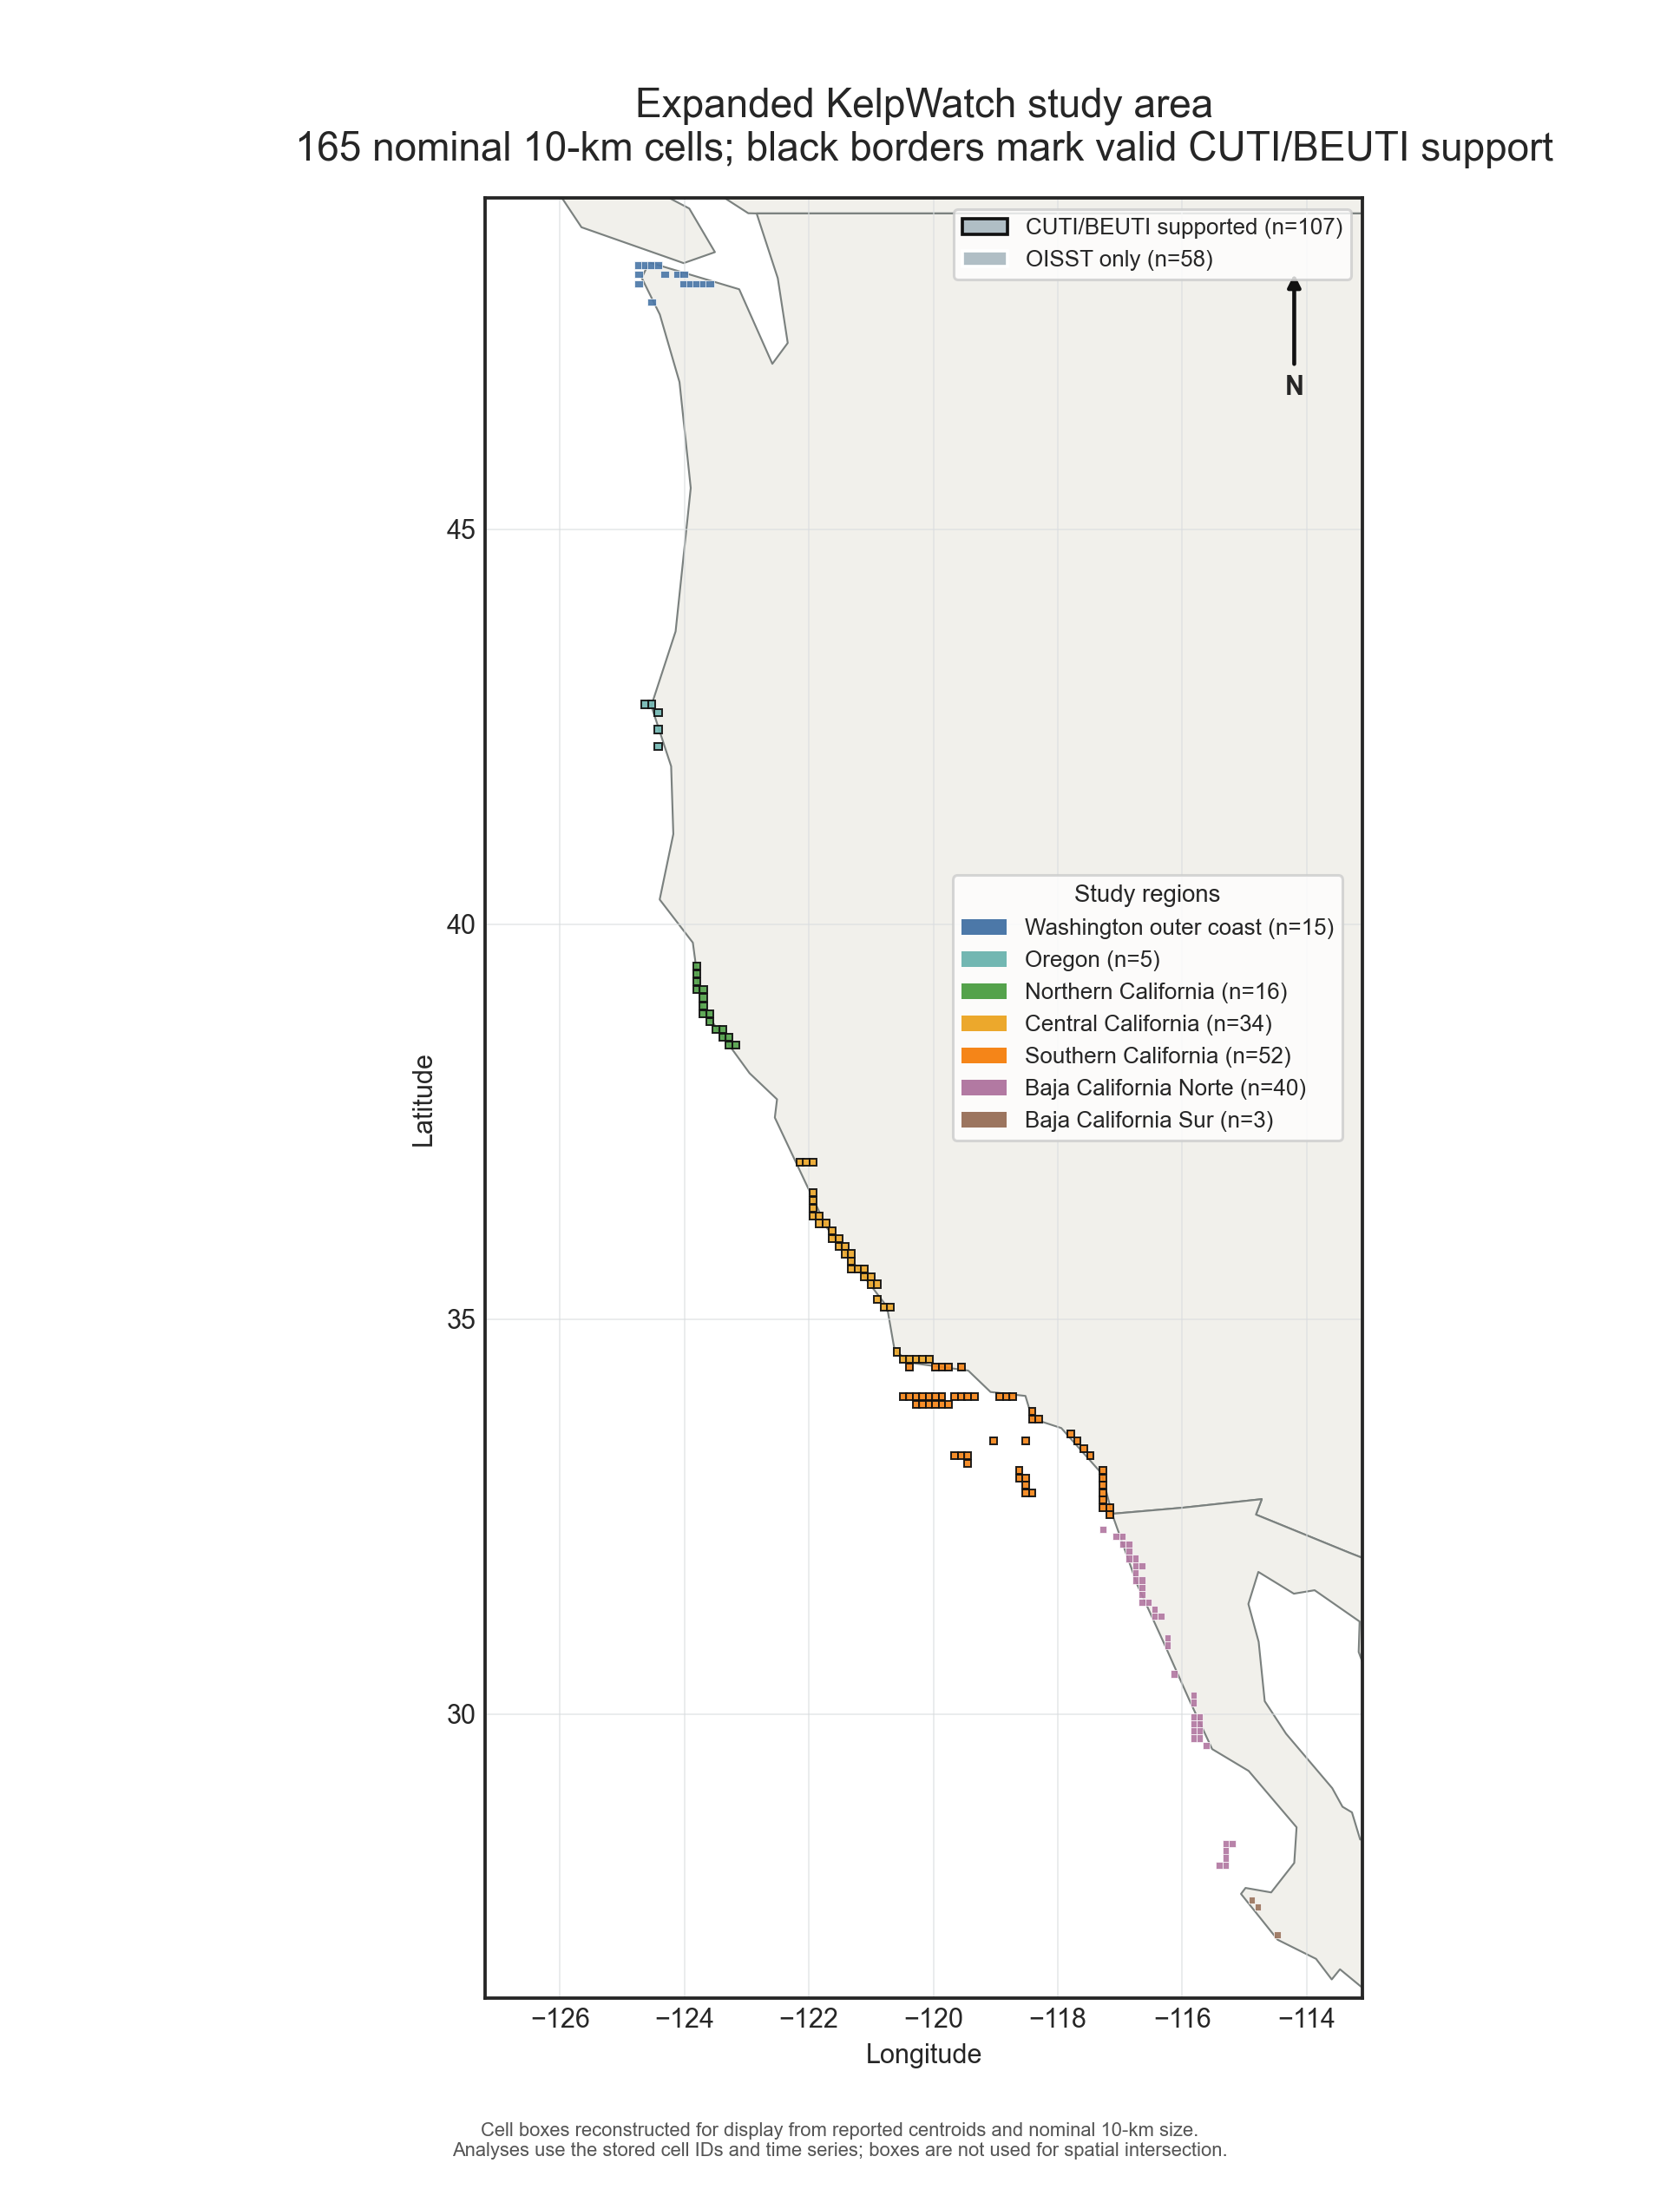

In [2]:
data_view = summary[["domain", "n", "cells", "events", "prevalence"]].drop_duplicates()
display(data_view.round(3))
display(env_checks)
display(Image(filename=str(RUN / "figure_00_study_area_165_cells.png"), width=850))

OISST는 165셀 전체의 86개 고유 해양 격자점에 매칭됐고, 가장 먼 대체 해양점은 27.8 km였다. CUTI/BEUTI는 공식 범위와 육상 경계를 모두 만족하는 미국 107셀에만 사용했다. Baja와 47°N 북쪽 Washington 셀에는 값을 복제하거나 외삽하지 않았다.

## Results 1 — 주 모델과 제한 예산 성능

,domain,model_label_ko,pooled_ap,macro_year_ap_lift,macro_region_year_ap_lift,top10_recall_micro,top20_recall_micro,brier,log_loss
0,full_oisst_domain,현재 상태,0.565,0.177,0.223,0.177,0.320,0.217,0.630
1,full_oisst_domain,현재+과거 변화,0.571,0.200,0.228,0.183,0.323,0.214,0.624
2,full_oisst_domain,현재+과거+OISST,0.544,0.178,0.228,0.174,0.305,0.222,0.643
3,upwelling_supported_domain,현재 상태,0.555,0.159,0.192,0.162,0.289,0.220,0.634
4,upwelling_supported_domain,현재+과거 변화,0.548,0.171,0.184,0.168,0.287,0.220,0.636
5,upwelling_supported_domain,현재+과거+OISST,0.520,0.162,0.194,0.157,0.280,0.230,0.659
6,upwelling_supported_domain,현재+과거+OISST+CUTI/BEUTI,0.508,0.159,0.207,0.159,0.278,0.236,0.679


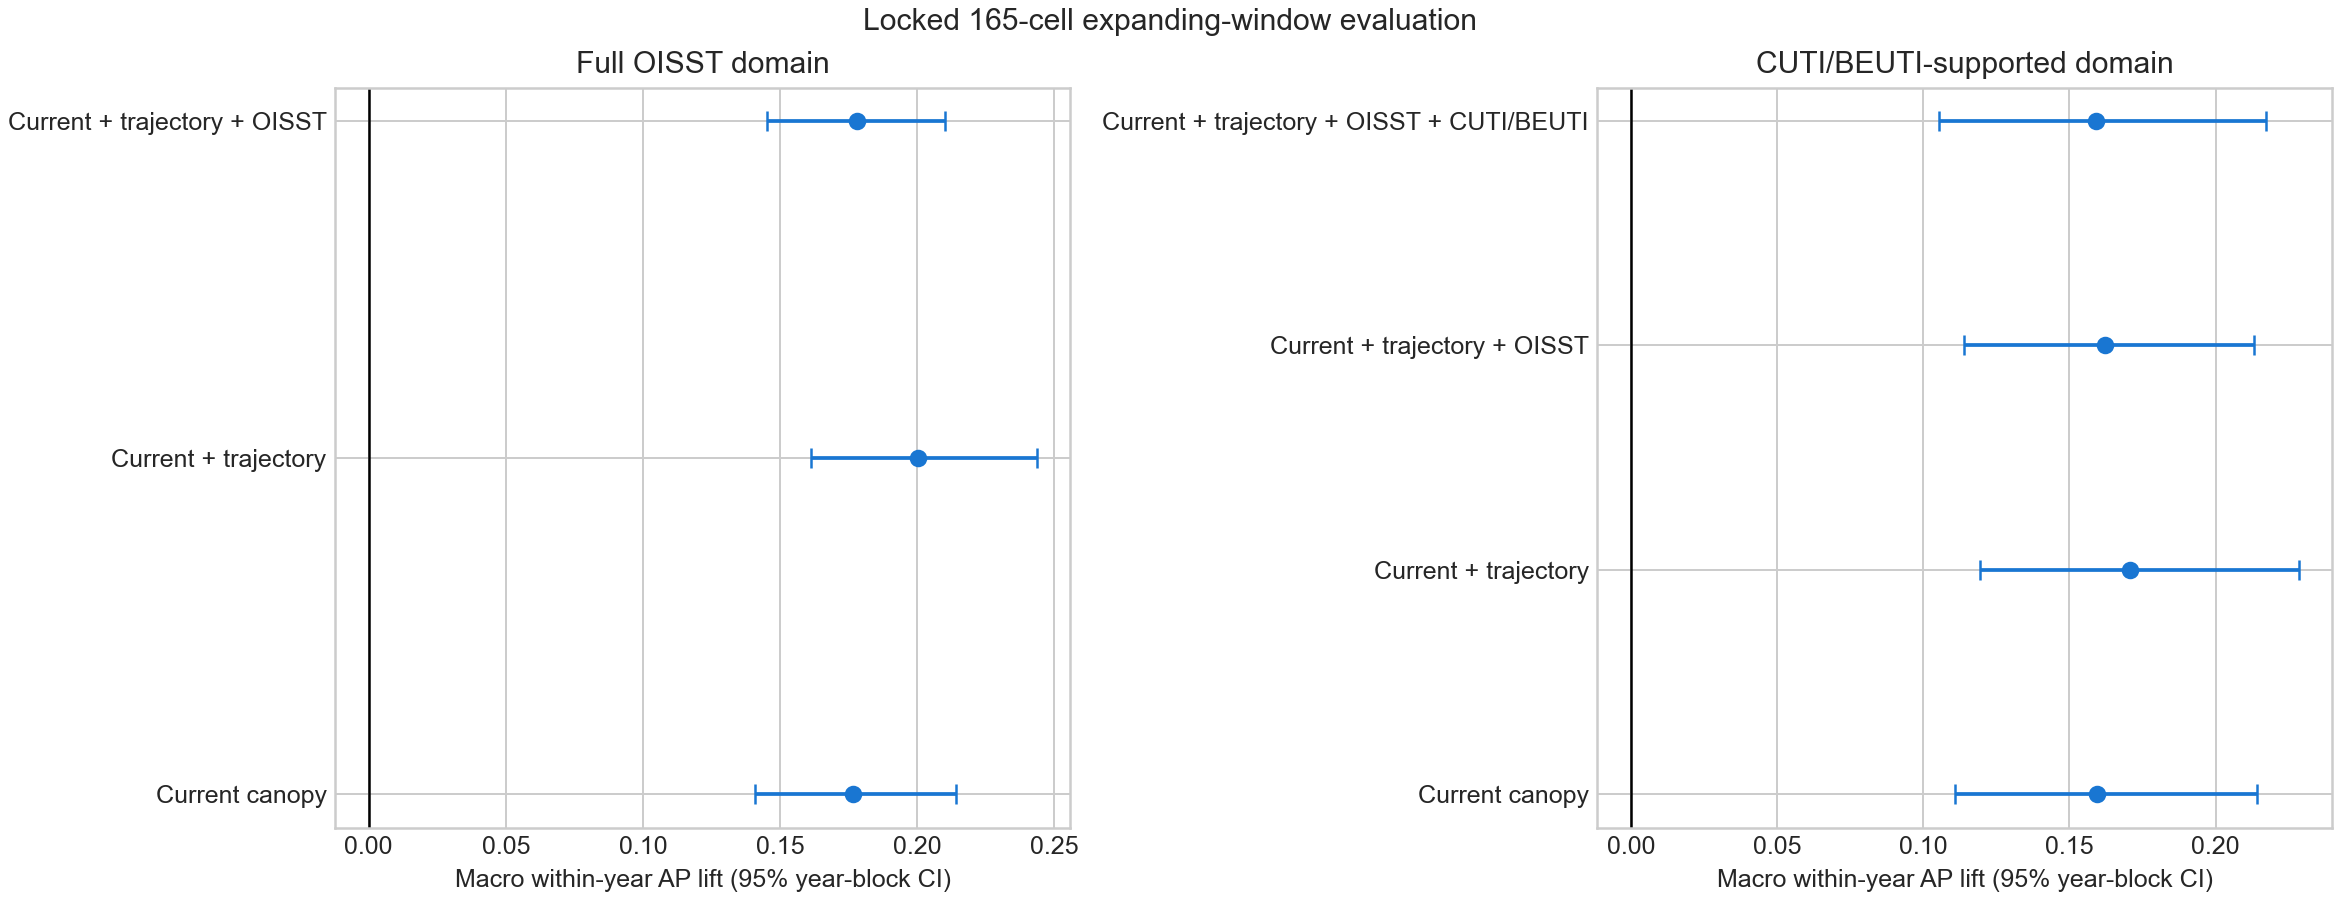

In [3]:
cols = [
    "domain", "model_label_ko", "pooled_ap", "macro_year_ap_lift",
    "macro_region_year_ap_lift", "top10_recall_micro", "top20_recall_micro",
    "brier", "log_loss",
]
display(summary[cols].round(3))
display(Image(filename=str(RUN / "figure_01_primary_model_comparison.png"), width=1050))

현재 상태 모델의 20% 예산 회수율은 32.0%다. 이는 후보 셀을 무작위로 20% 조사할 때의 기대 회수율보다 높지만, 사건의 약 68%는 놓친다. 따라서 현장조사 후보를 줄이는 보조 순위로 해석하며 복원 대상지 자동선정으로 표현하지 않는다.

## Results 2 — 과거 변화와 NOAA의 순수 추가가치

,domain,scope,comparison,estimate,ci_low,ci_high,supported_positive
0,full_oisst_domain,year,trajectory_minus_current,0.024,0.006,0.045,True
1,full_oisst_domain,year,oisst_minus_trajectory,-0.023,-0.055,0.006,False
2,full_oisst_domain,region_year,trajectory_minus_current,0.005,-0.021,0.033,False
3,full_oisst_domain,region_year,oisst_minus_trajectory,0.000,-0.018,0.018,False
4,upwelling_supported_domain,year,trajectory_minus_current,0.011,-0.010,0.034,False
5,upwelling_supported_domain,year,oisst_minus_trajectory,-0.009,-0.029,0.009,False
6,upwelling_supported_domain,year,cuti_beuti_minus_oisst,-0.003,-0.026,0.026,False
7,upwelling_supported_domain,region_year,trajectory_minus_current,-0.008,-0.031,0.021,False
8,upwelling_supported_domain,region_year,oisst_minus_trajectory,0.010,-0.000,0.021,False
9,upwelling_supported_domain,region_year,cuti_beuti_minus_oisst,0.013,-0.007,0.035,False


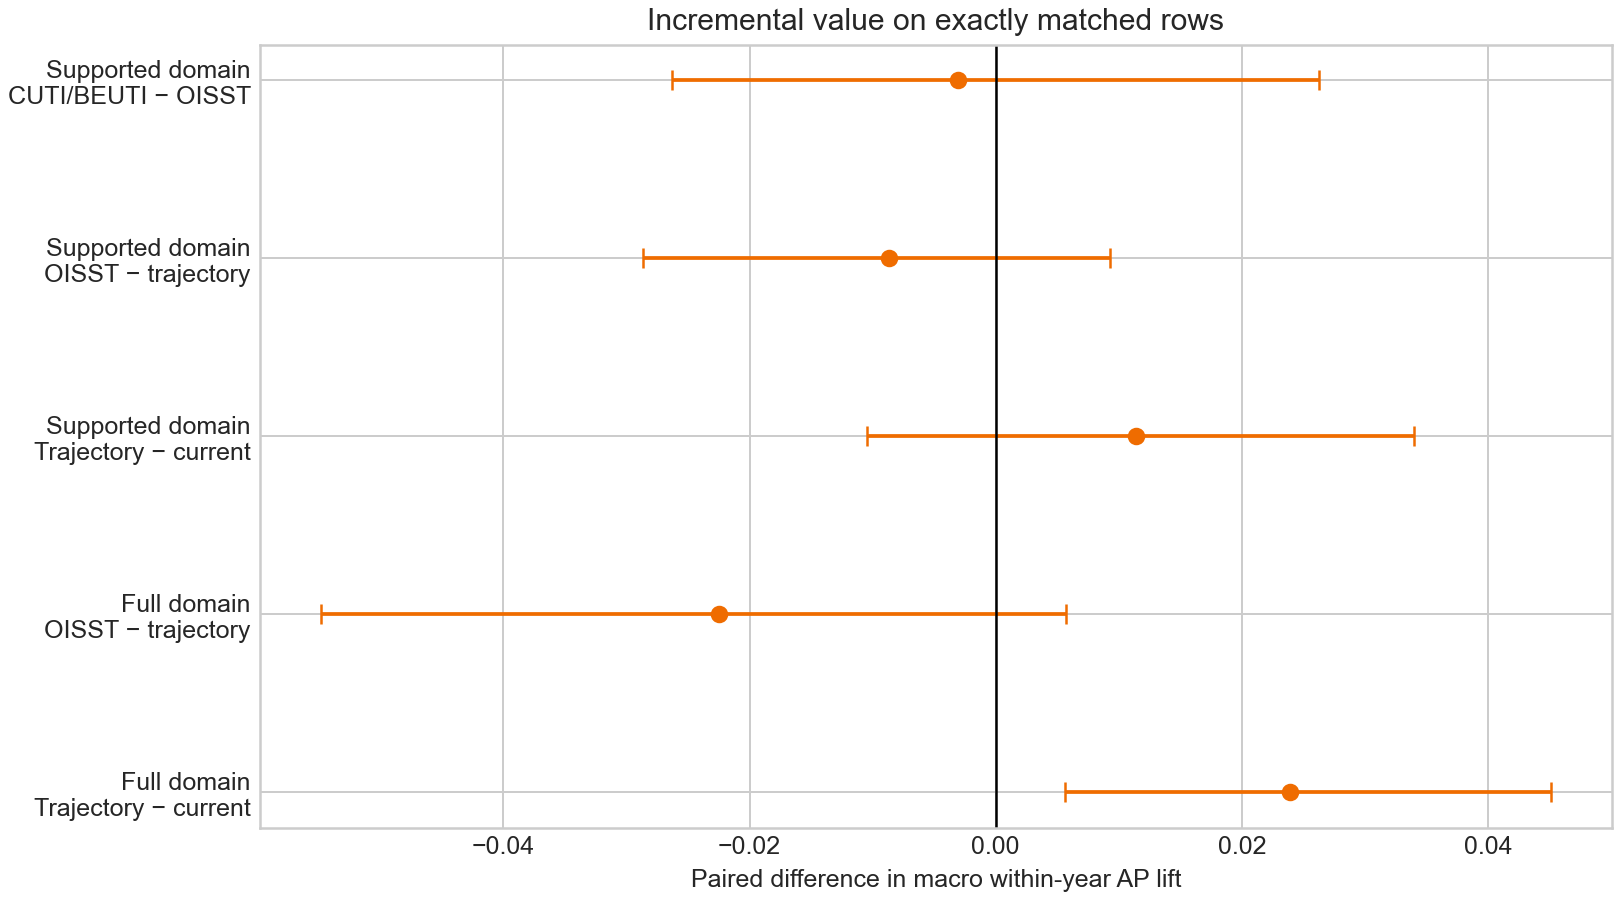

In [4]:
display(diffs[["domain", "scope", "comparison", "estimate", "ci_low", "ci_high", "supported_positive"]].round(3))
display(Image(filename=str(RUN / "figure_02_incremental_value.png"), width=1100))

과거 변화는 165셀 연도 내 평균에서 작지만 양의 증분을 보였다. 다만 region-year 평균과 U.S. 지원영역에서는 신뢰구간이 0을 포함했고, Top-20% 사건 회수율 증가는 0.3%p였다. OISST와 CUTI/BEUTI는 각각 바로 앞 모델에 비해 신뢰구간이 0을 포함했다. 이는 **환경이 생태적으로 중요하지 않다**는 결과가 아니라, 이 해상도·예측시점·라벨·모델에서는 과거 캐노피 이후 추가 예측정보가 확인되지 않았다는 결과다.

## Results 3 — 2022 및 특정 연도 의존성

,model,scenario,macro_year_ap_lift,top20_recall_micro
0,current_only,all_years,0.177,0.320
1,current_only,exclude_2022,0.177,0.324
2,current_plus_trajectory,all_years,0.200,0.323
3,current_plus_trajectory,exclude_2022,0.200,0.328
4,trajectory_plus_oisst,all_years,0.178,0.305
5,trajectory_plus_oisst,exclude_2022,0.180,0.309


,model,min,max
0,current_only,0.169,0.185
1,current_plus_trajectory,0.188,0.208
2,trajectory_plus_oisst,0.172,0.186


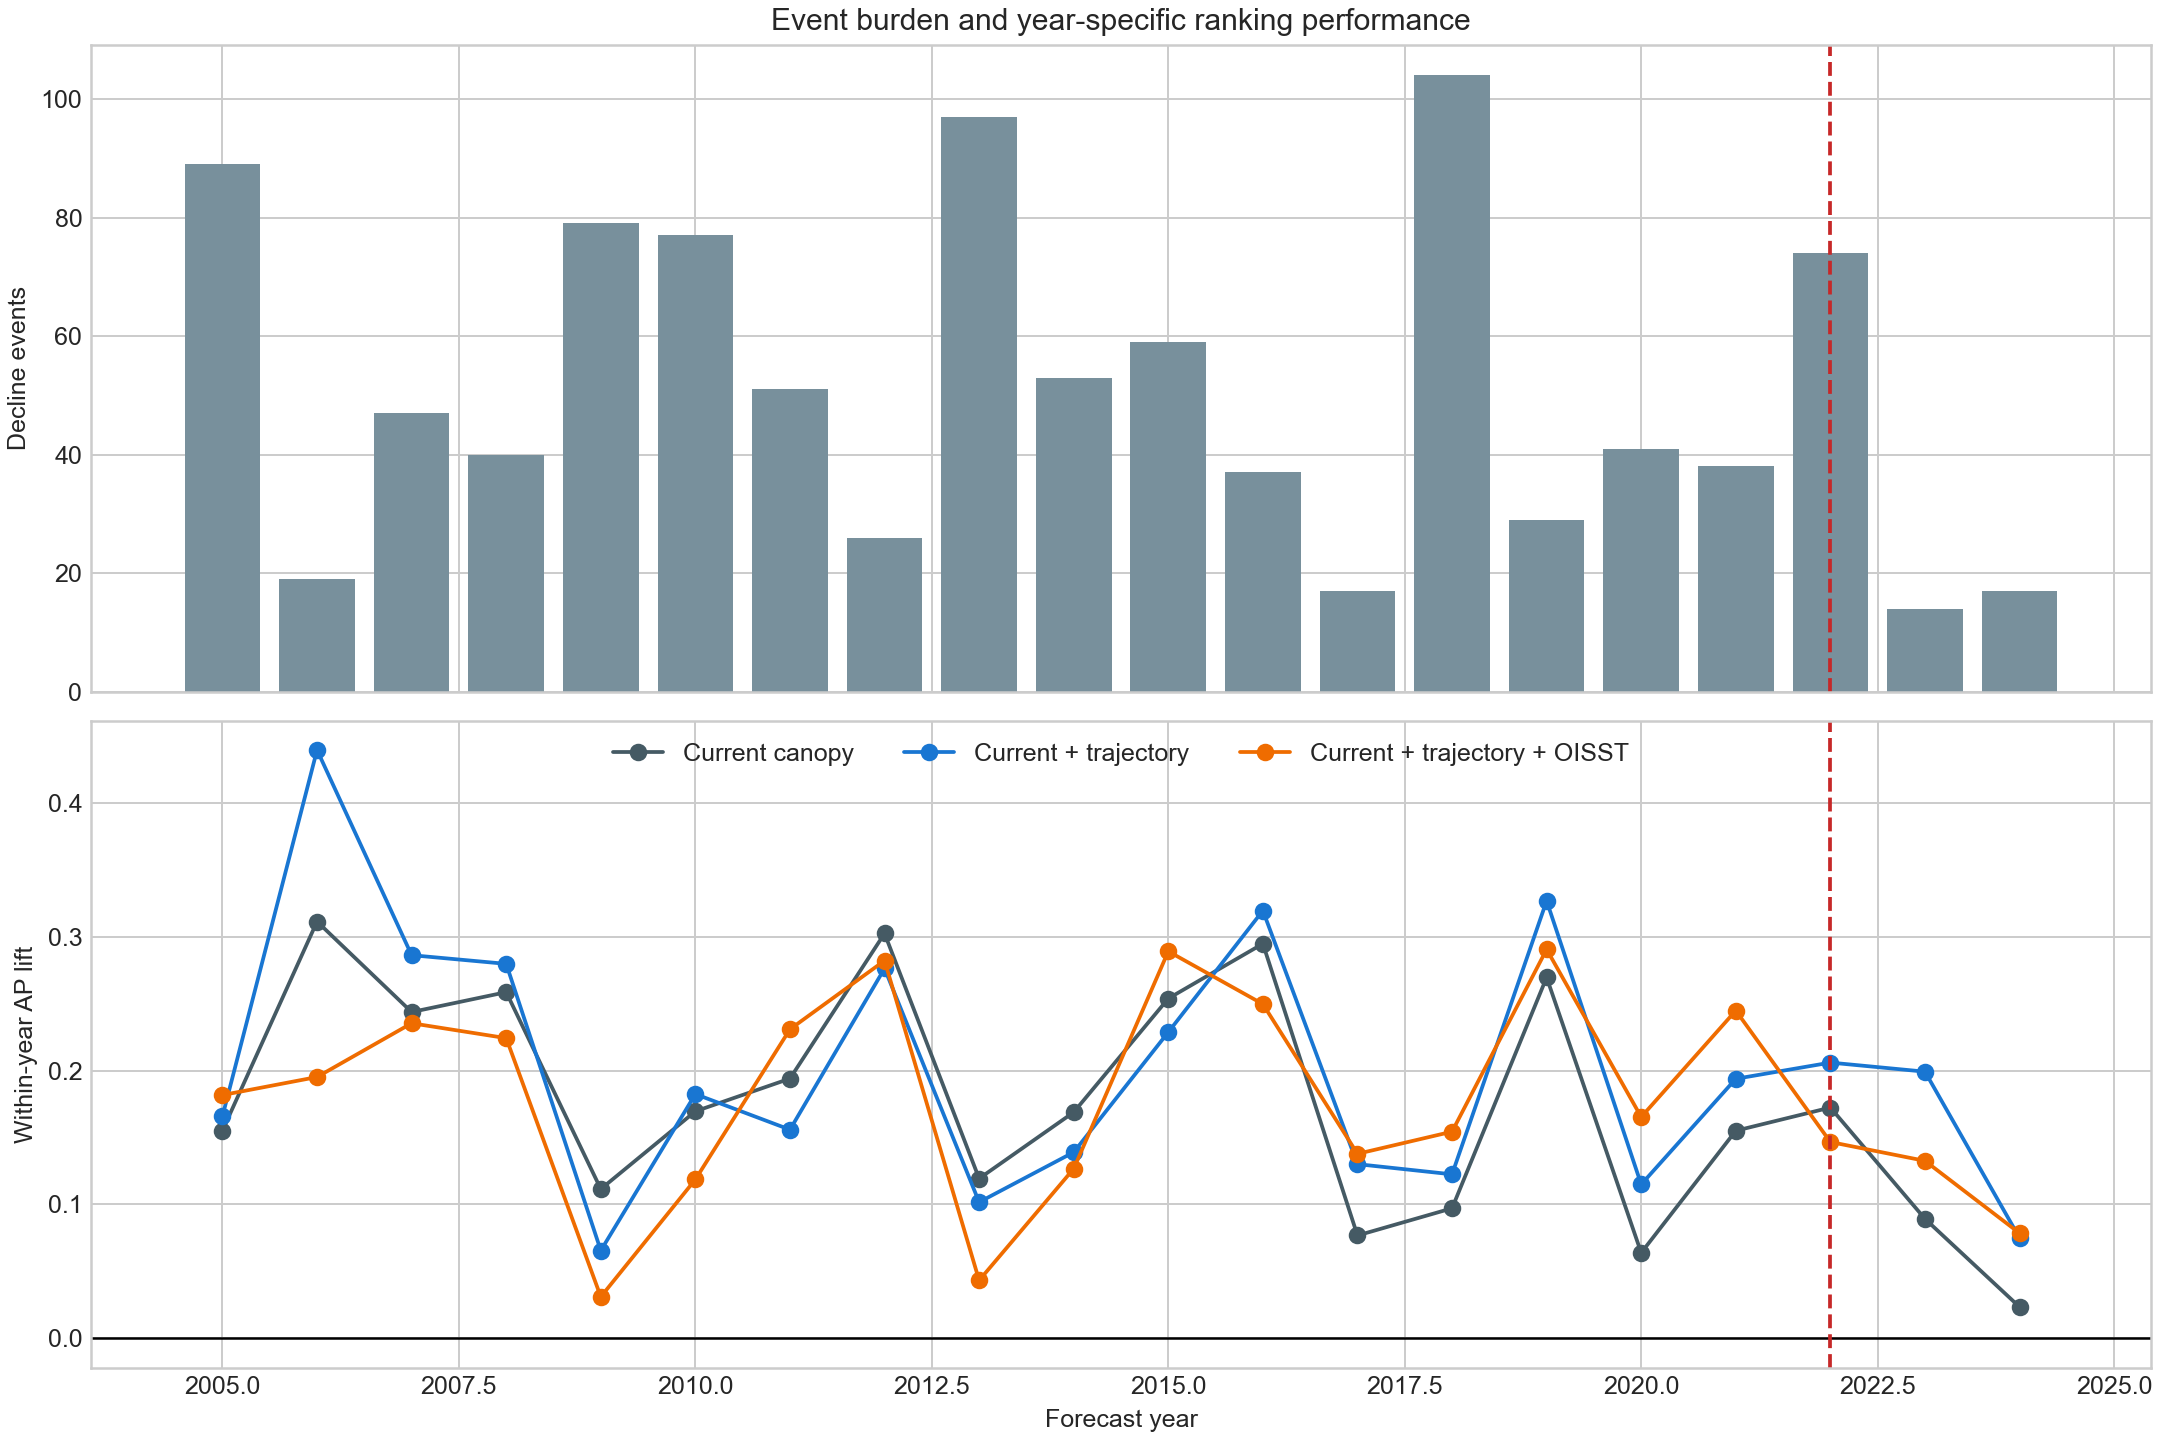

In [5]:
full_stress = stress[stress["domain"].eq("full_oisst_domain")]
display(full_stress[["model", "scenario", "macro_year_ap_lift", "top20_recall_micro"]].round(3))

loyo_full = loyo[loyo["domain"].eq("full_oisst_domain")]
loyo_range = loyo_full.groupby("model")["macro_year_ap_lift"].agg(["min", "max"]).reset_index()
display(loyo_range.round(3))
display(Image(filename=str(RUN / "figure_03_year_dependence.png"), width=1050))

2022 제외 전후 current-only macro lift는 0.1765→0.1768, trajectory는 0.2004→0.2001로 사실상 변하지 않았다. leave-one-year-out 범위도 모두 양수여서 결과가 2022년이나 하나의 특정 연도에만 의존한다는 설명은 지지되지 않는다.

## Results 4 — 미관측 지역으로의 전이

,held_region,model,cells,events,macro_year_ap_lift,top20_recall_micro
0,Baja California Norte,current_only,40,255,0.169,0.290
1,Baja California Norte,current_plus_trajectory,40,255,0.164,0.286
2,Baja California Norte,trajectory_plus_oisst,40,255,0.174,0.282
3,Central California,current_only,34,203,0.125,0.256
4,Central California,current_plus_trajectory,34,203,0.100,0.236
5,Central California,trajectory_plus_oisst,34,203,0.113,0.246
6,Northern California,current_only,16,74,0.287,0.318
7,Northern California,current_plus_trajectory,16,74,0.282,0.341
8,Northern California,trajectory_plus_oisst,16,74,0.271,0.318
9,Southern California,current_only,52,351,0.190,0.279


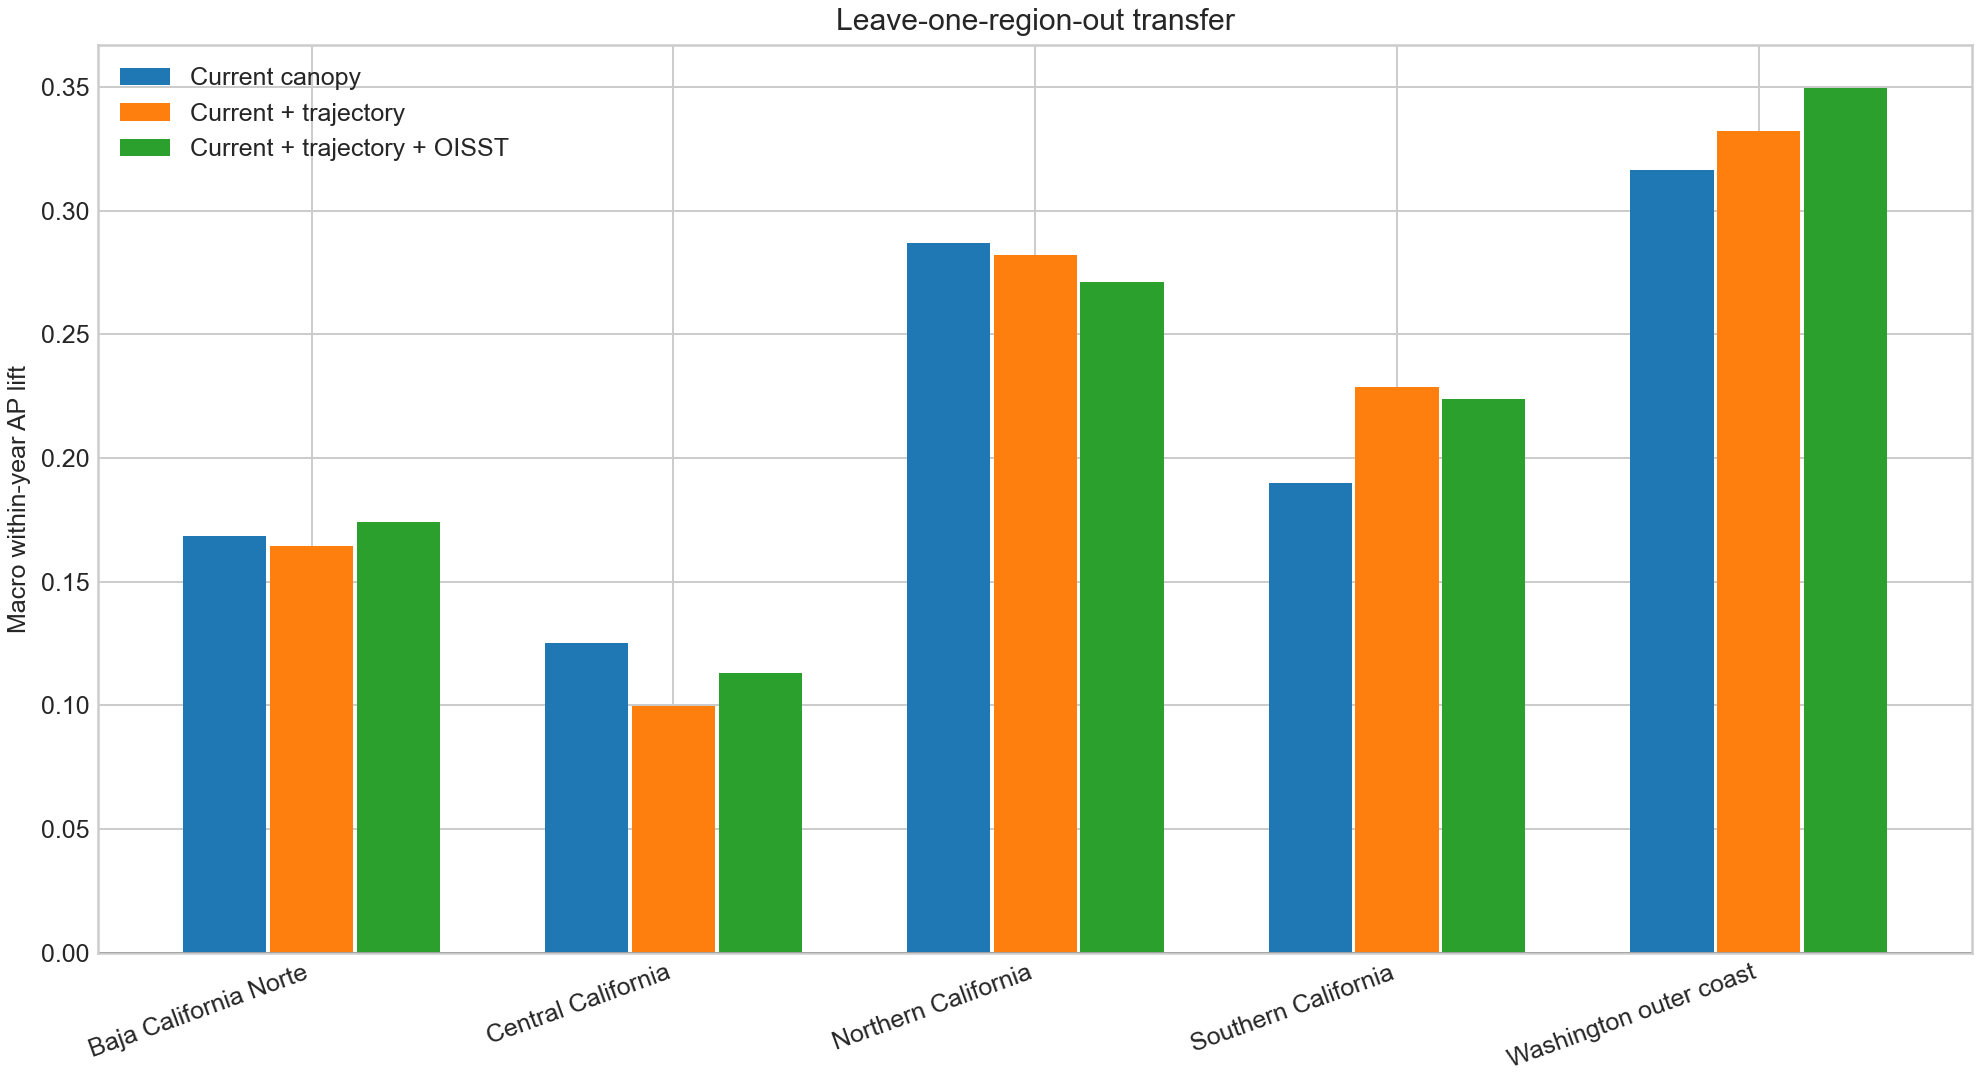

In [6]:
display(transfer[["held_region", "model", "cells", "events", "macro_year_ap_lift", "top20_recall_micro"]].round(3))
display(Image(filename=str(RUN / "figure_04_leave_region_out.png"), width=1100))

모든 보류 지역에서 current-only의 macro within-year AP lift는 양수였다. 그러나 궤적과 OISST가 current-only보다 항상 좋지는 않았다. 따라서 **기본 순위 신호의 지리적 전이 가능성**은 보고할 수 있지만, **추가 변수의 보편적 지역 일반화**는 주장하지 않는다. 북부 캘리포니아는 추정 가능한 연도가 7개뿐이라는 제한도 함께 제시해야 한다.

## Takeaways

1. 발표·논문의 RQ1 문구는 “가능한가?”를 유지할 수 있고, 답은 이 데이터에서 **가능**이다.
2. RQ2의 정직한 답은 “과거 변화는 통계적으로 작은 개선, NOAA proxy는 확인된 추가가치 없음”이다.
3. RQ3은 “2022 및 단일 연도 의존성은 낮고 기본 순위화는 지역 보류에서도 양수지만, 증분효과는 공간적으로 불안정”으로 제한한다.
4. 논문의 기여는 환경 기작 발견이 아니라 **공개 위성·광역 환경자료로 만든 운영 순위의 시간·공간·예산 외부평가**다.
5. 다음 단계에서 환경변수를 유지한다면, 직접 원인변수라고 쓰지 말고 광역 노출 proxy로 정의하며 계절창·공간 support·지원범위를 명시한다.